# 07. Baseline Modeling & Temporal Validation

## Objective

첫 구매 시점까지 확인 가능한 Feature만 사용하여
90일 재구매 고객의 우선순위를 예측한다.

Primary Target:

`repeat_90d_after_1h`

평가는 실제 운영 상황을 모사하기 위해
Random Split이 아닌 First-Purchase Date 기준
Time-Based Split을 사용한다.

비교 대상:

1. Rule-Based Baseline
2. Logistic Regression

Primary Evaluation:

- PR-AUC
- Precision@K
- Recall@K
- Lift@K

In [1]:
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [2]:
conn = sqlite3.connect(
    "../data/processed/olist.db"
)

model_df = pd.read_sql_query(
    """
    SELECT
        f.*,
        y.first_purchase_month,
        y.repeat_90d_after_1h

    FROM first_purchase_feature_base AS f

    JOIN customer_repeat_90d_base AS y
        ON f.customer_unique_id
            = y.customer_unique_id

    WHERE
        y.is_eligible_90d = 1
    """,
    conn
)

conn.close()

In [3]:
print(
    model_df.shape
)

print(
    model_df[
        "repeat_90d_after_1h"
    ]
    .value_counts()
)

(78505, 24)
repeat_90d_after_1h
0    77423
1     1082
Name: count, dtype: int64


# Time-Based Split

Train
~ 2017-12-31

Validation
2018-01-01 ~ 2018-03-31

Test
2018-04-01 ~ 2018-06-05

In [4]:
model_df[
    "first_approved_at"
] = pd.to_datetime(
    model_df[
        "first_approved_at"
    ]
)

train_df = (
    model_df[
        model_df[
            "first_approved_at"
        ] < "2018-01-01"
    ]
    .copy()
)

validation_df = (
    model_df[
        (
            model_df[
                "first_approved_at"
            ] >= "2018-01-01"
        )
        &
        (
            model_df[
                "first_approved_at"
            ] < "2018-04-01"
        )
    ]
    .copy()
)

test_df = (
    model_df[
        model_df[
            "first_approved_at"
        ] >= "2018-04-01"
    ]
    .copy()
)

In [5]:
for name, df in [
    ("Train", train_df),
    ("Validation", validation_df),
    ("Test", test_df)
]:

    print(
        name,
        len(df),
        df[
            "repeat_90d_after_1h"
        ].sum(),
        f"{df['repeat_90d_after_1h'].mean():.2%}"
    )

Train 43916 617 1.40%
Validation 20420 263 1.29%
Test 14169 202 1.43%


In [6]:
# Training Period에서 Multi-Item Rule 방향 확인

train_rule_analysis_df = (
    train_df[
        train_df[
            "first_item_count"
        ].notna()
    ]
    .copy()
)

train_rule_analysis_df[
    "multi_item_order"
] = (
    train_rule_analysis_df[
        "first_item_count"
    ] >= 2
)

train_rule_summary = (
    train_rule_analysis_df
    .groupby(
        "multi_item_order"
    )
    ["repeat_90d_after_1h"]
    .agg(
        [
            "count",
            "sum",
            "mean"
        ]
    )
)

train_rule_summary

,count,sum,mean
multi_item_order,,,
False,39180,538,0.013731
True,4274,74,0.017314


In [7]:
# Feature 정의

## Numeric
numeric_features = [
    "first_item_count",
    "first_distinct_product_count",
    "first_seller_count",
    "first_item_value",
    "first_freight_value",
    "first_freight_ratio",
    "first_avg_item_price",
    "first_payment_record_count",
    "first_payment_type_count",
    "first_payment_value",
    "first_max_payment_installments",
    "first_category_count",
    "missing_category_item_count"
]

## Categorical
categorical_features = [
    "customer_state",
    "purchase_weekday",
    "purchase_hour",
    "primary_payment_type",
    "primary_category"
]

In [8]:
# X/y 분리
feature_columns = (
    numeric_features
    + categorical_features
)

X_train = (
    train_df[
        feature_columns
    ]
)

y_train = (
    train_df[
        "repeat_90d_after_1h"
    ]
)

X_validation = (
    validation_df[
        feature_columns
    ]
)

y_validation = (
    validation_df[
        "repeat_90d_after_1h"
    ]
)

X_test = (
    test_df[
        feature_columns
    ]
)

y_test = (
    test_df[
        "repeat_90d_after_1h"
    ]
)

In [9]:
# Numeric Pipeline
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [10]:
# Categorical Pipeline
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [11]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [12]:
# Logistic Regression Baseline
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['first_item_count','first_distinct_product_count','first_seller_count', ...,'purchase_hour','primary_payment_type','primary_category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are drop

In [13]:
# Validation Prediction
validation_probability = (
    logistic_model
    .predict_proba(
        X_validation
    )[:, 1]
)

In [14]:
validation_pr_auc = (
    average_precision_score(
        y_validation,
        validation_probability
    )
)

validation_roc_auc = (
    roc_auc_score(
        y_validation,
        validation_probability
    )
)

print(
    "Validation PR-AUC:",
    validation_pr_auc
)

print(
    "Validation ROC-AUC:",
    validation_roc_auc
)

Validation PR-AUC: 0.017482764064690542
Validation ROC-AUC: 0.5738994520391354


In [15]:
# Top-K
def evaluate_top_k(
    y_true,
    probability,
    k_ratio
):

    evaluation_df = pd.DataFrame(
        {
            "y_true": y_true.to_numpy(),
            "probability": probability
        }
    )

    evaluation_df = (
        evaluation_df
        .sort_values(
            "probability",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    k = int(
        len(evaluation_df)
        * k_ratio
    )

    top_k_df = (
        evaluation_df
        .head(k)
    )

    precision_at_k = (
        top_k_df[
            "y_true"
        ]
        .mean()
    )

    recall_at_k = (
        top_k_df[
            "y_true"
        ]
        .sum()
        /
        evaluation_df[
            "y_true"
        ]
        .sum()
    )

    base_rate = (
        evaluation_df[
            "y_true"
        ]
        .mean()
    )

    lift_at_k = (
        precision_at_k
        / base_rate
    )

    return {
        "k_ratio": k_ratio,
        "customer_count": k,
        "precision_at_k": precision_at_k,
        "recall_at_k": recall_at_k,
        "lift_at_k": lift_at_k
    }

In [16]:
# 5% / 10% / 20% Capacity
logistic_validation_result = pd.DataFrame(
    [
        evaluate_top_k(
            y_validation,
            validation_probability,
            0.05
        ),
        evaluate_top_k(
            y_validation,
            validation_probability,
            0.10
        ),
        evaluate_top_k(
            y_validation,
            validation_probability,
            0.20
        )
    ]
)

logistic_validation_result

,k_ratio,customer_count,precision_at_k,recall_at_k,lift_at_k
0,0.05,1021,0.018609,0.072243,1.444867
1,0.10,2042,0.019589,0.152091,1.520913
2,0.20,4084,0.017630,0.273764,1.368821


In [17]:
# Rule-Based Baseline
validation_df[
    "rule_score"
] = (
    validation_df[
        "first_item_count"
    ]
    .fillna(0)
)

validation_df[
    "rule_score"
] = (
    validation_df[
        "first_item_count"
    ]
    .fillna(0)
    >= 2
).astype(int)

In [18]:
# Rule Top-K 처리
rule_target_df = (
    validation_df[
        validation_df[
            "first_item_count"
        ].fillna(0) >= 2
    ]
)

rule_precision = (
    rule_target_df[
        "repeat_90d_after_1h"
    ]
    .mean()
)

rule_recall = (
    rule_target_df[
        "repeat_90d_after_1h"
    ]
    .sum()
    /
    validation_df[
        "repeat_90d_after_1h"
    ]
    .sum()
)

rule_lift = (
    rule_precision
    /
    validation_df[
        "repeat_90d_after_1h"
    ]
    .mean()
)

print(
    "Rule customers:",
    len(rule_target_df)
)

print(
    "Rule Precision:",
    rule_precision
)

print(
    "Rule Recall:",
    rule_recall
)

print(
    "Rule Lift:",
    rule_lift
)

Rule customers: 1990
Rule Precision: 0.021608040201005024
Rule Recall: 0.1634980988593156
Rule Lift: 1.6777041099031278


In [19]:
# 동일한 운영 용량 비교
rule_capacity = (
    len(rule_target_df)
    / len(validation_df)
)

rule_capacity

0.09745347698334966

In [20]:
logistic_same_capacity = (
    evaluate_top_k(
        y_validation,
        validation_probability,
        rule_capacity
    )
)

logistic_same_capacity

{'k_ratio': 0.09745347698334966,
 'customer_count': 1990,
 'precision_at_k': np.float64(0.019597989949748745),
 'recall_at_k': np.float64(0.1482889733840304),
 'lift_at_k': np.float64(1.5216386113074882)}

In [21]:
# Final Model Training
# Train + Validation을 합쳐 최종 모델을 다시 학습한다.

development_df = pd.concat(
    [
        train_df,
        validation_df
    ],
    ignore_index=True
)

X_development = (
    development_df[
        feature_columns
    ]
)

y_development = (
    development_df[
        "repeat_90d_after_1h"
    ]
)

print(
    "Development customers:",
    len(
        development_df
    )
)

print(
    "Development repeat customers:",
    y_development.sum()
)

print(
    "Development repeat rate:",
    f"{y_development.mean():.2%}"
)

Development customers: 64336
Development repeat customers: 880
Development repeat rate: 1.37%


In [22]:
# Final Logistic Regression

final_logistic_model = clone(
    logistic_model
)

final_logistic_model.fit(
    X_development,
    y_development
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['first_item_count','first_distinct_product_count','first_seller_count', ...,'purchase_hour','primary_payment_type','primary_category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are drop

In [23]:
# Final Test Prediction

test_probability = (
    final_logistic_model
    .predict_proba(
        X_test
    )[:, 1]
)

In [24]:
test_pr_auc = (
    average_precision_score(
        y_test,
        test_probability
    )
)

test_roc_auc = (
    roc_auc_score(
        y_test,
        test_probability
    )
)

print(
    "Final Test PR-AUC:",
    test_pr_auc
)

print(
    "Final Test ROC-AUC:",
    test_roc_auc
)

Final Test PR-AUC: 0.016929917575705264
Final Test ROC-AUC: 0.5263520731682246


In [25]:
test_top_k_result = pd.DataFrame(
    [
        evaluate_top_k(
            y_test,
            test_probability,
            0.05
        ),
        evaluate_top_k(
            y_test,
            test_probability,
            0.10
        ),
        evaluate_top_k(
            y_test,
            test_probability,
            0.20
        )
    ]
)

test_top_k_result

,k_ratio,customer_count,precision_at_k,recall_at_k,lift_at_k
0,0.05,708,0.026836,0.094059,1.882384
1,0.10,1416,0.016949,0.118812,1.188874
2,0.20,2833,0.016943,0.237624,1.188454


In [26]:
def evaluate_top_n(
    y_true,
    probability,
    customer_count
):

    evaluation_df = pd.DataFrame(
        {
            "y_true": y_true.to_numpy(),
            "probability": probability
        }
    )

    evaluation_df = (
        evaluation_df
        .sort_values(
            "probability",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    top_n_df = (
        evaluation_df
        .head(
            customer_count
        )
    )

    precision = (
        top_n_df[
            "y_true"
        ]
        .mean()
    )

    recall = (
        top_n_df[
            "y_true"
        ]
        .sum()
        /
        evaluation_df[
            "y_true"
        ]
        .sum()
    )

    base_rate = (
        evaluation_df[
            "y_true"
        ]
        .mean()
    )

    lift = (
        precision
        / base_rate
    )

    return {
        "customer_count": customer_count,
        "captured_repeat": int(
            top_n_df[
                "y_true"
            ]
            .sum()
        ),
        "precision": precision,
        "recall": recall,
        "lift": lift
    }

In [27]:
test_rule_df = (
    test_df[
        test_df[
            "first_item_count"
        ]
        .fillna(0) >= 2
    ]
)

test_rule_customer_count = (
    len(
        test_rule_df
    )
)

test_rule_precision = (
    test_rule_df[
        "repeat_90d_after_1h"
    ]
    .mean()
)

test_rule_recall = (
    test_rule_df[
        "repeat_90d_after_1h"
    ]
    .sum()
    /
    test_df[
        "repeat_90d_after_1h"
    ]
    .sum()
)

test_rule_lift = (
    test_rule_precision
    /
    test_df[
        "repeat_90d_after_1h"
    ]
    .mean()
)

print(
    "Test Rule customers:",
    test_rule_customer_count
)

print(
    "Test Rule captured repeat:",
    test_rule_df[
        "repeat_90d_after_1h"
    ].sum()
)

print(
    "Test Rule Precision:",
    test_rule_precision
)

print(
    "Test Rule Recall:",
    test_rule_recall
)

print(
    "Test Rule Lift:",
    test_rule_lift
)

Test Rule customers: 1466
Test Rule captured repeat: 32
Test Rule Precision: 0.021828103683492497
Test Rule Recall: 0.15841584158415842
Test Rule Lift: 1.5311009955020058


In [28]:
test_logistic_same_capacity = (
    evaluate_top_n(
        y_test,
        test_probability,
        test_rule_customer_count
    )
)

test_logistic_same_capacity

{'customer_count': 1466,
 'captured_repeat': 24,
 'precision': np.float64(0.01637107776261937),
 'recall': np.float64(0.1188118811881188),
 'lift': np.float64(1.1483257466265044)}

In [29]:
validation_comparison_df = pd.DataFrame(
    {
        "method": [
            "Multi-Item Rule",
            "Logistic Regression"
        ],
        "lift": [
            rule_lift,
            logistic_same_capacity[
                "lift_at_k"
            ]
        ],
        "captured_repeat": [
            int(
                rule_target_df[
                    "repeat_90d_after_1h"
                ]
                .sum()
            ),
            int(
                logistic_same_capacity[
                    "recall_at_k"
                ]
                * y_validation.sum()
            )
        ]
    }
)

validation_comparison_df

,method,lift,captured_repeat
0,Multi-Item Rule,1.677704,43
1,Logistic Regression,1.521639,39


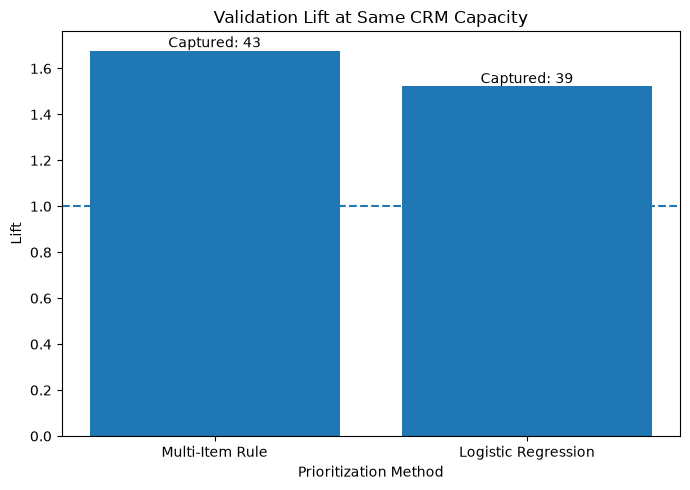

In [30]:
plt.figure(
    figsize=(7, 5)
)

bars = plt.bar(
    validation_comparison_df[
        "method"
    ],
    validation_comparison_df[
        "lift"
    ]
)

plt.axhline(
    y=1.0,
    linestyle="--"
)

plt.title(
    "Validation Lift at Same CRM Capacity"
)

plt.ylabel(
    "Lift"
)

plt.xlabel(
    "Prioritization Method"
)

for bar, captured in zip(
    bars,
    validation_comparison_df[
        "captured_repeat"
    ]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"Captured: {captured}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "../reports/figures/model_lift_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [31]:
test_comparison_df = pd.DataFrame(
    {
        "method": [
            "Multi-Item Rule",
            "Logistic Regression"
        ],
        "lift": [
            test_rule_lift,
            test_logistic_same_capacity[
                "lift"
            ]
        ],
        "captured_repeat": [
            int(
                test_rule_df[
                    "repeat_90d_after_1h"
                ]
                .sum()
            ),
            test_logistic_same_capacity[
                "captured_repeat"
            ]
        ]
    }
)

test_comparison_df

,method,lift,captured_repeat
0,Multi-Item Rule,1.531101,32
1,Logistic Regression,1.148326,24


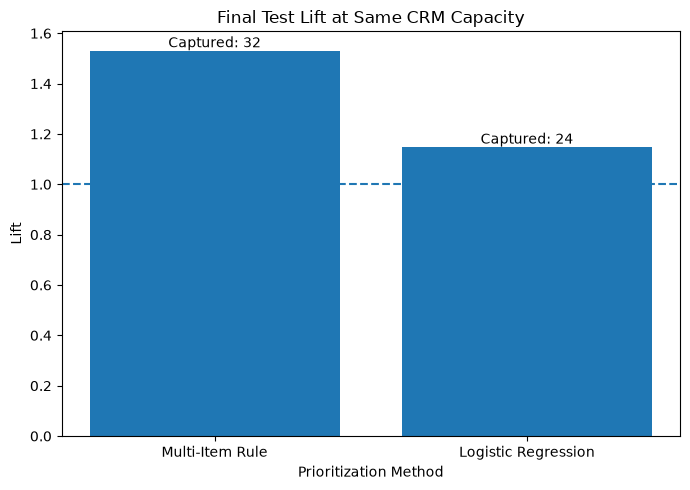

In [32]:
plt.figure(
    figsize=(7, 5)
)

bars = plt.bar(
    test_comparison_df[
        "method"
    ],
    test_comparison_df[
        "lift"
    ]
)

plt.axhline(
    y=1.0,
    linestyle="--"
)

plt.title(
    "Final Test Lift at Same CRM Capacity"
)

plt.ylabel(
    "Lift"
)

plt.xlabel(
    "Prioritization Method"
)

for bar, captured in zip(
    bars,
    test_comparison_df[
        "captured_repeat"
    ]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"Captured: {captured}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "../reports/figures/model_lift_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [33]:
test_pr_auc = (
    average_precision_score(
        y_test,
        test_probability
    )
)

test_roc_auc = (
    roc_auc_score(
        y_test,
        test_probability
    )
)

print(
    "Test PR-AUC:",
    test_pr_auc
)

print(
    "Test ROC-AUC:",
    test_roc_auc
)

Test PR-AUC: 0.016929917575705264
Test ROC-AUC: 0.5263520731682246
